# Avito Orientation Classification

## Задача

Задачей было для каждого изображения оценить вероятность того, что текст
на нём повёрнут на 180 градусов.

Основаня метрика:

$$
Brier = \frac{1}{N}\sum_i (p_i-y_i)^2,
\qquad
Score = 1 - Brier.
$$

Поэтому важна не только доля правлиьных ответов, но и само значение вероятностных предсказаний

## 1. Анализ данных

В тестовой выборке находится 20000 изображений, они разного размера и у них разное соотношение сторон.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
TEST_DIR = PROJECT_ROOT / "data" / "test"

files = sorted(TEST_DIR.glob("*.png"))

print(f"{len(files):,} изображений")

20,000 изображений


In [2]:
records = []

for path in tqdm(files):
    with Image.open(path) as img:
        w, h = img.size

        records.append({
            "filename": path.name,
            "width": w,
            "height": h,
            "aspect_ratio": w / h,
            "mode": img.mode,
        })

df = pd.DataFrame(records)

df.head()

100%|██████████| 20000/20000 [00:00<00:00, 21866.36it/s]


,filename,width,height,aspect_ratio,mode
0,test_00000.png,73,25,2.920000,RGB
1,test_00001.png,119,19,6.263158,RGB
2,test_00002.png,1584,269,5.888476,RGB
3,test_00003.png,55,12,4.583333,RGB
4,test_00004.png,145,28,5.178571,RGB


In [3]:
df.describe(percentiles=[.01, .05, .1, .25, .5, .75, .9, .95, .99])

,width,height,aspect_ratio
count,20000.000000,20000.000000,20000.000000
mean,357.603600,64.398150,6.220858
std,318.933591,59.337019,4.267151
min,25.000000,10.000000,0.720930
1%,40.000000,12.000000,1.761886
5%,61.000000,16.000000,2.319909
10%,79.000000,18.000000,2.688264
25%,129.000000,27.000000,3.503241
50%,238.000000,42.000000,4.894899
75%,479.250000,76.000000,7.518636


Можем заметить, что медианное соотношение сторон ~5, а максимальное ~50, при этом 90 персентиль соответствует AR $\approx$ 12.

В качестве основной высоты выбрана высота 64 px, все картинки масштабируются именно до нее. Максимальная ширина 768 px (12 * 64), если картинка оказалась с AR > 12, то она сжимается до 768, если же картинка оказалась короче, то она зполняется белым цветом до 768px.

Такой препроцессинг применяется для основной части выборки, но в процессе эксперемента выяснилось, что сильно страдает качество на строках, чем AR > 20. Для таких строк предполагается отдельная предобработка, которая опишется позже.

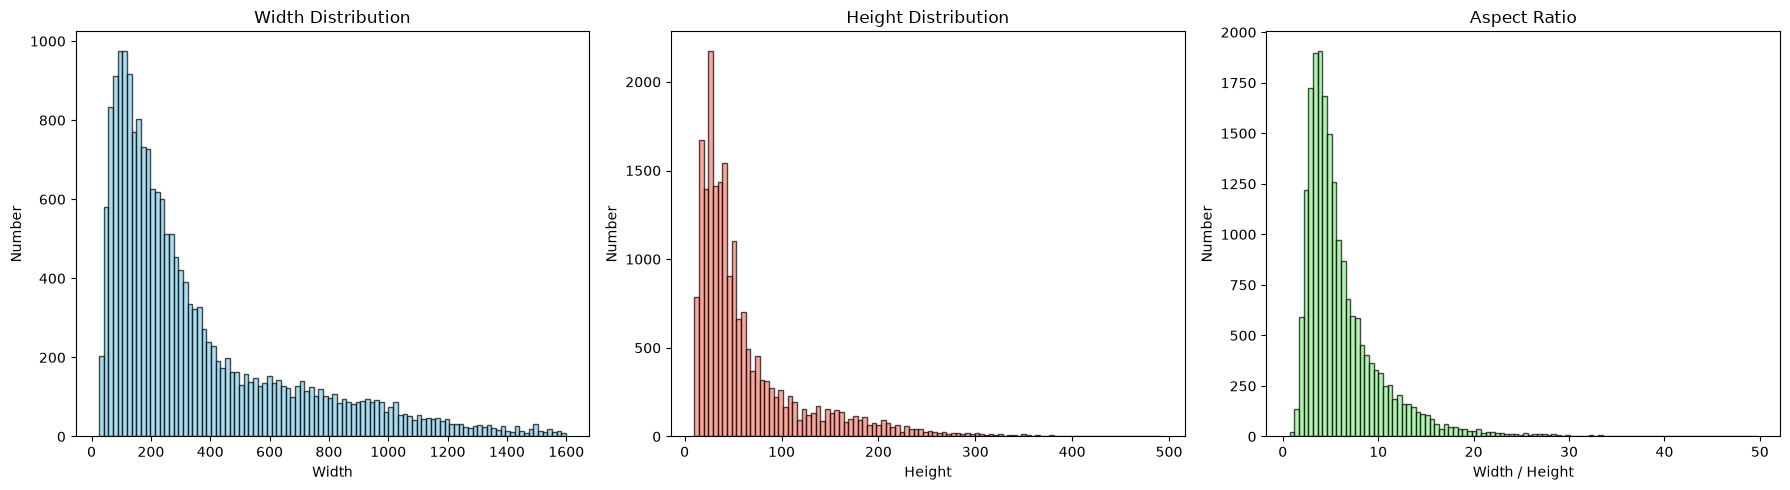

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

axes[0].hist(df["width"], bins=100, color="skyblue", edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Width")
axes[0].set_ylabel("Number")
axes[0].set_title("Width Distribution")

axes[1].hist(df["height"], bins=100, color="salmon", edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Height")
axes[1].set_ylabel("Number")
axes[1].set_title("Height Distribution")

axes[2].hist(df["aspect_ratio"], bins=100, color="lightgreen", edgecolor="black", alpha=0.7)
axes[2].set_xlabel("Width / Height")
axes[2].set_ylabel("Number")
axes[2].set_title("Aspect Ratio")

plt.tight_layout()

plt.show()


In [5]:
def show_images(rows, cols=4, figsize=(16, 10)):
    rows = rows.reset_index(drop=True)
    n = len(rows)
    r = int(np.ceil(n / cols))

    fig, axes = plt.subplots(r, cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for i, row in rows.iterrows():
        img = Image.open(TEST_DIR / row["filename"])

        axes[i].imshow(img)
        axes[i].set_title(
            f'{row["filename"]}\n'
            f'{row["width"]}×{row["height"]}, '
            f'AR={row["aspect_ratio"]:.1f}'
        )
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

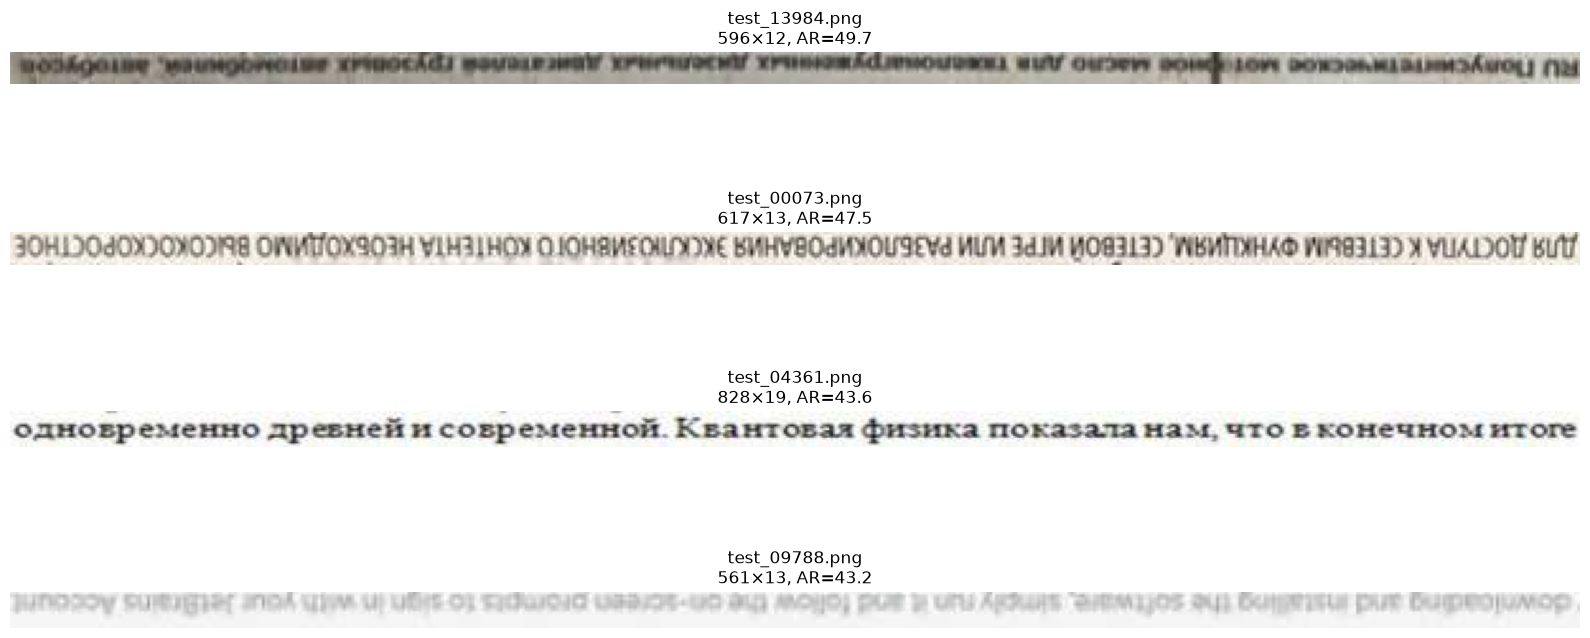

In [32]:
show_images(
    df.nlargest(4, "aspect_ratio"),
    cols=1,
    figsize=(16, 8)
)

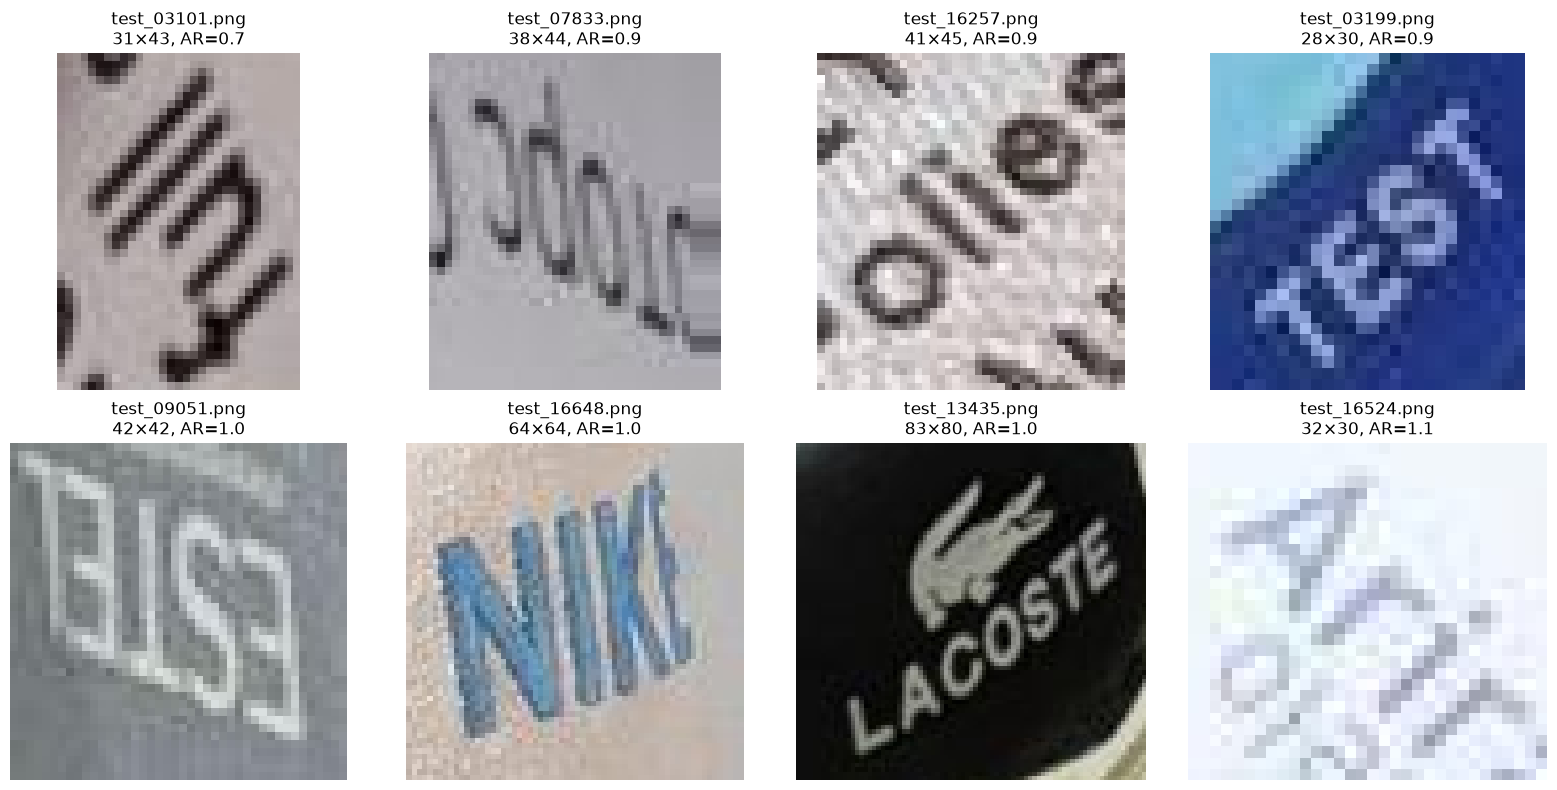

In [31]:
show_images(
    df.nsmallest(8, "aspect_ratio"),
    cols=4,
    figsize=(16, 8)
)

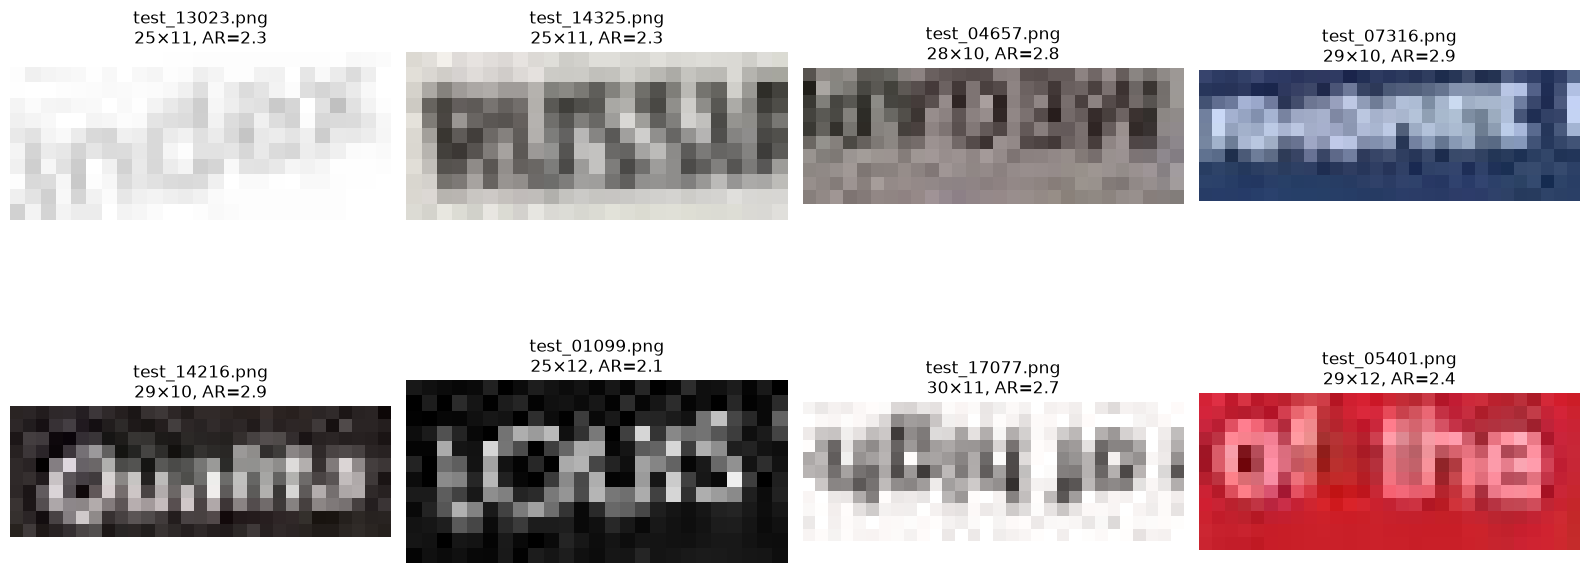

In [30]:
df["area"] = df["width"] * df["height"]

show_images(
    df.nsmallest(8, "area"),
    cols=4,
    figsize=(16, 8)
)

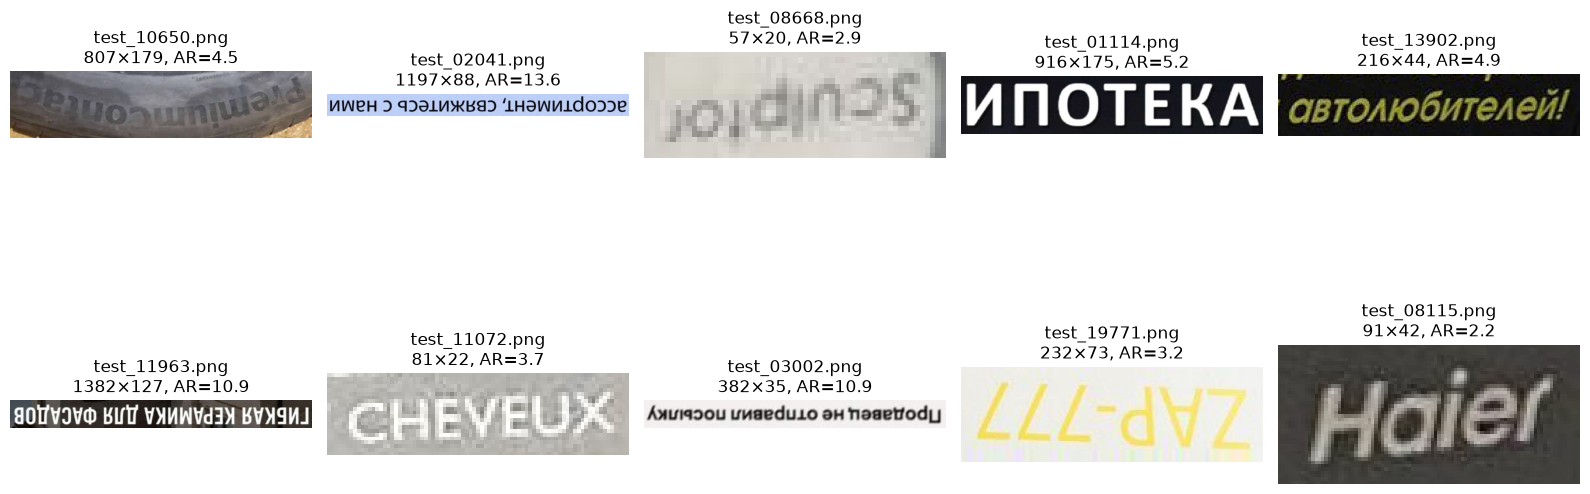

In [29]:
show_images(
    df.sample(10, random_state=42),
    cols=5,
    figsize=(16, 8)
)

Распределения размеров, экстремальные случаи и примеры изображений показаны сверху. Можем заметить, что в выборке присутствуют русские и английские названия и предложения, числа, короткие названия и длинные строки с разным фоном контрастом цветом и шрифтом.

## 2. Обучающие данные

Размеченной обучающей выборки в задаче нет, поэтому использовались открытые OCR датасеты:
- TextOCR - для обучающая выборка
- ICDAR2015 OCR - независимая валидационная выборка

Использование разных валидационной и обучающей выборки повышает уверенность в обобщительной способности модели, так как метрики считаются на независимом датасете, а не на подмножестве обучающего.

Разметку ориентации можно сделать очень легко. Во время обучения исходное изображение с вероятностью 0.5 остаётся без изменений (y=0), иначе поворачивается на 180 градусов (y=1).
На валидации для каждого исходного изображения создаются обе ориентации. Поэтому классы идеально сбалансированы, а метрика не зависит от случайной генерации ориентации.


In [35]:
from datasets import load_dataset

In [36]:
train_ds = load_dataset(
    "MiXaiLL76/TextOCR_OCR",
    split="train",
)

val_ds = load_dataset(
    "MiXaiLL76/ICDAR2015_OCR",
    split="train",
)

print(train_ds.features)
print(val_ds.features)

print(train_ds)
print(val_ds)

{'image': Image(mode=None, decode=True), 'text': Value('string')}
{'image': Image(mode=None, decode=True), 'text': Value('string')}
Dataset({
    features: ['image', 'text'],
    num_rows: 91373
})
Dataset({
    features: ['image', 'text'],
    num_rows: 4468
})


## 3. Аугментации

Для увеличения соответствия между тренироваочным и тестовым датасетом были использованы следующие аугментации:

- афинные преобразования
- изменение перспективы
- гауссовское размытие
- гауссовский шум
- изменение яркости и контраста
- JPEG сжатие
- уменьшение разрешения

Параметры были подобраны таким образом, чтобы текст на картинке не потерял читаемость и было возможно определить является ли он перевернутым. Аугментации продемонстрированы ниже

In [37]:

from torch.utils.data import DataLoader
from avito_orientation.dataset import OrientationDataset

In [39]:
train_data = OrientationDataset(
    train_ds,
    train=True,
)

val_data = OrientationDataset(
    val_ds,
    train=False,
)

loader = DataLoader(
    train_data,
    batch_size=16,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)

images, labels = next(iter(loader))

In [40]:
def show_augmentations(dataset, augment, indices=None, n_aug=5):
    if indices is None:
        indices = [10, 100, 1000, 5000]

    fig, axes = plt.subplots(
        len(indices),
        n_aug + 1,
        figsize=(18, 3 * len(indices)),
    )

    for row, idx in enumerate(indices):
        image = dataset[idx]["image"].convert("RGB")
        image_np = np.array(image)

        axes[row, 0].imshow(image)
        axes[row, 0].set_title(
            f"Original\n{image.size[0]}×{image.size[1]}"
        )
        axes[row, 0].axis("off")

        for col in range(1, n_aug + 1):
            augmented = augment(image=image_np)["image"]

            axes[row, col].imshow(augmented)
            axes[row, col].set_title(f"Aug #{col}")
            axes[row, col].axis("off")

    plt.tight_layout()

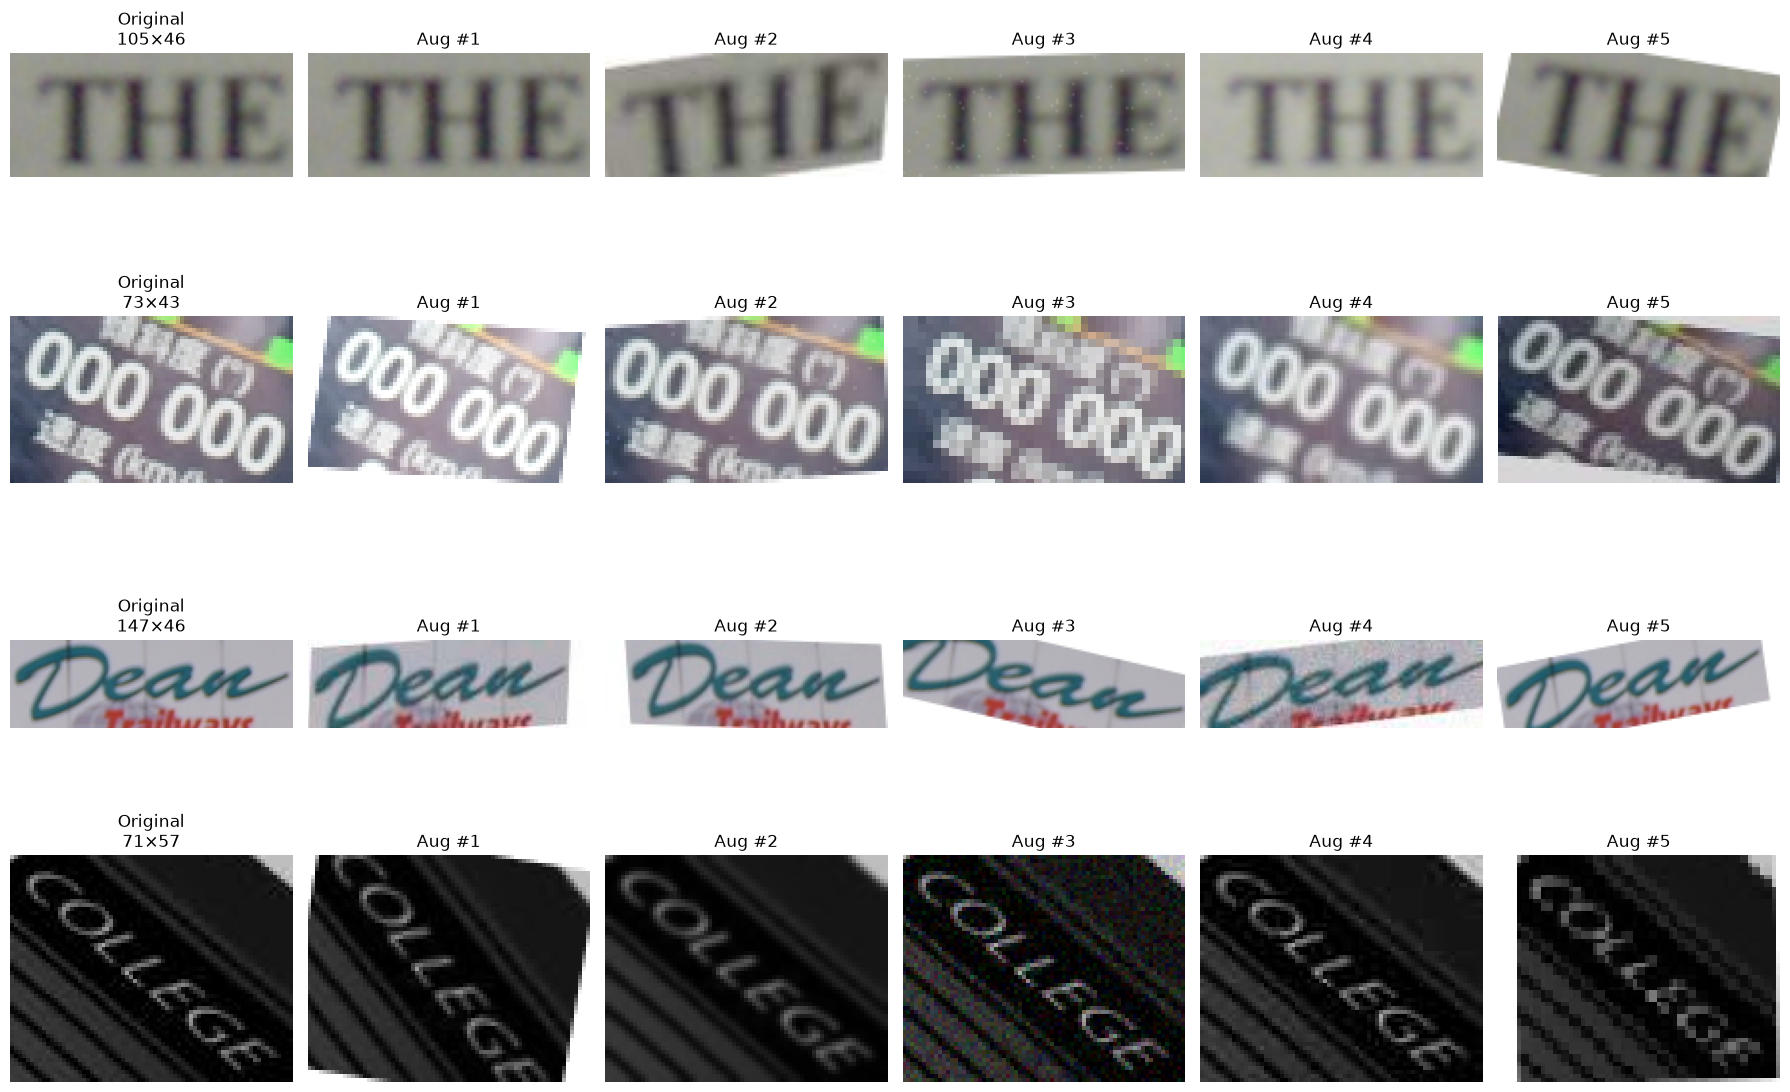

In [42]:
show_augmentations(
    train_ds,
    train_data.augment,
    indices=[10, 100, 1000, 5000],
    n_aug=5,
)

## 4. Cинтетические кириллические данные

Поскольку в данных присутствуют надписи на кириллице, к обучению были добавленны синтетически сгенерированные русскоязычные строки. Генератор создает слова, фразы, числа, номера и коды на различных фонах и с различными шрифтами (шрифты до запуска кода необходимо загрузить отдельно), а после этого к изображениям применяются те же аугментации, что и к тренировочной выборке.

Поскольку TextOCR преимущественно не покрывает разнообразие кириллических строк тестовой выборки, дополнительно был проверен вариант обучения с синтетическими русскоязычными изображениями.

In [14]:
from avito_orientation.synthetic import SyntheticCyrillicDataset

In [20]:
synthetic = SyntheticCyrillicDataset(
    size=50_000,
)

print("fonts:", len(synthetic.fonts))

fonts: 63


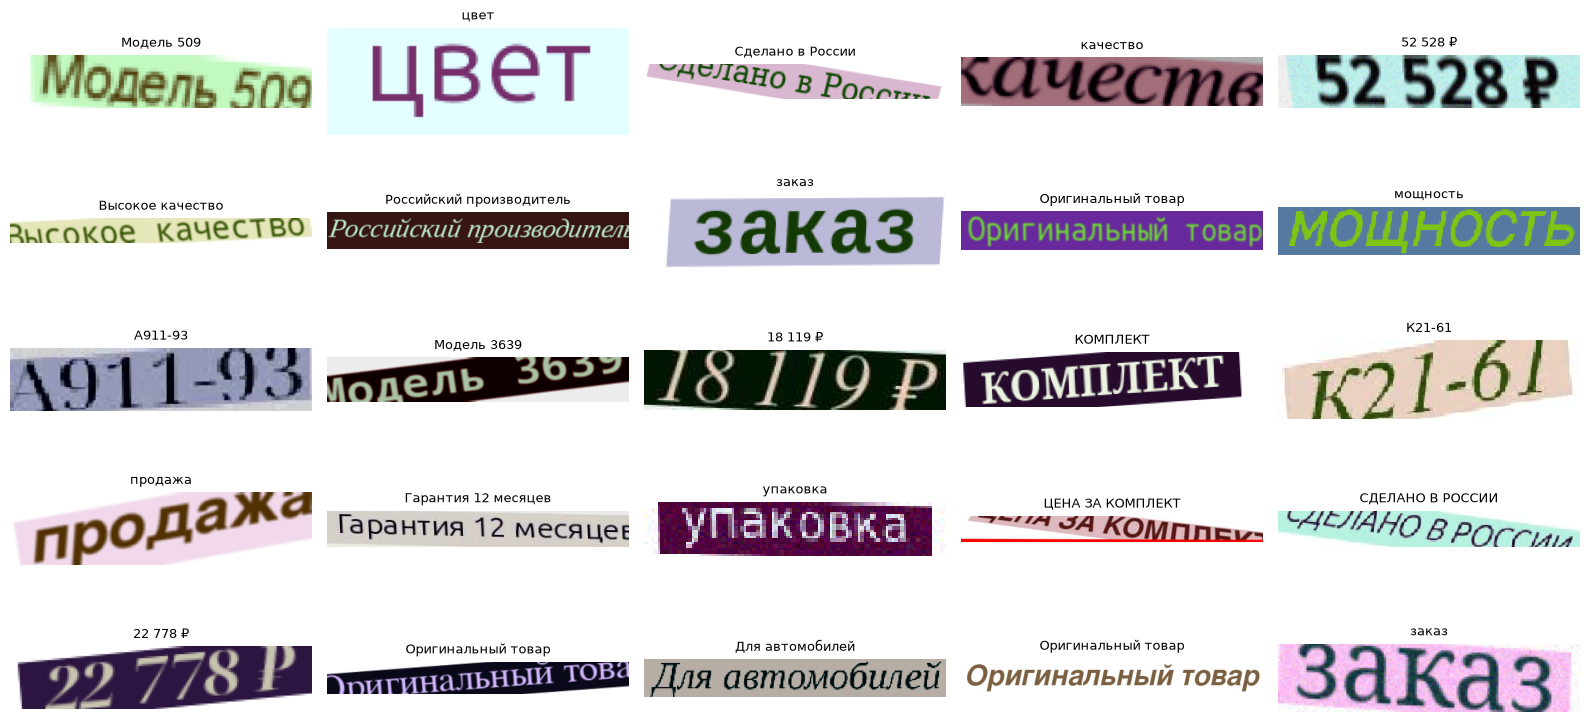

In [43]:
fig, axes = plt.subplots(
    5,
    5,
    figsize=(16, 8),
)

for i, ax in enumerate(axes.flat):
    sample = synthetic[i]
    image_np = np.array(sample["image"])

    aug = train_data.augment(
        image=image_np,
    )["image"]

    ax.imshow(aug)
    ax.set_title(
        sample["text"],
        fontsize=9,
    )
    ax.axis("off")

plt.tight_layout()

## 5. Обучение

Все архитектуры инициализировались предобученными версиями и дообучались как бинарные классификаторы с одним выходным логитом.
Основная конфигурация:
- BCEWithLogitsLoss
- optimizer AdamW
- weight decay 1e-4;
- cosine annealing learning rate
- input height 64 px
- maximum width 768 px
- лучшая модель выбиралась по Brier Score на валидационном датасете.

Для основных моделей использовались batch_size=64 и начальный learning rate=5e-5.
Первые эксперименты проводились в течение 8 эпох. Поскольку лучшая DINOv3-модель продолжала улучшаться к концу обучения, отдельно был запущен финальный эксперимент с 16 эпохами и тем же начальным learning rate.

## 6. Выбор архитектуры !

Были проверены несколько современных CNN гибридных архитектур. Основное сравнение ниже использует одинаковую ICDAR2015 validation и корректный 180 TTA.

| Модель | Параметры | Validation Score |
|---|---:|---:|
| ConvNeXtV2-Tiny | 27.87M | 0.961414 |
| CAFormer-S18 | ~26M | 0.954983 |
| ConvNeXtV2-Base | 87.69M | 0.964727 |
| ConvNeXt DINOv3 Small | ~50M | 0.965725 |
| ConvNeXt DINOv3 Base | ~88M | 0.968861 |

DINOv3-pretraining дал заметный прирост качества. DINOv3 Small превзошёл более крупный ConvNeXtV2 Base, а DINOv3 Base показал лучший результат среди одиночных моделей.

Таким образом, улучшение связано не только с увеличением размера backbone, так как выбор предобучения так же оказался существенным для задачи.

## 7. 180 Test Time Augmentation

У задачи есть интересная симметрия. Если `R(x)` — изображение, повёрнутое на 180°, то для идеального классификатора:

$$
P(y=1\mid x)=1-P(y=1\mid R(x)).
$$

Поэтому итоговая вероятность вычисляется как

$$
p_{\mathrm{TTA}}(x)=
\frac{p(x)+\left(1-p(R(x))\right)}{2}.
$$

Поворот выполняется над исходным изображением изменения его размеров и паддига, так как если повернуть уже подготовленную картинку, то белый паддинг переместится с правой стороны на левую и создаст распределение входов, которого модель не видела при обучении.

Для DINOv3 Base:

| Режим | Brier Score ↓ | Score ↑ |
|---|---:|---:|
| Без TTA | 0.045871 | 0.954129 |
| 180° TTA | 0.031139 | 0.968861 |

Средняя ошибка симметрии

$$
|p(x)-(1-p(R(x)))|
$$

для этой модели составила `0.0491`.

Таким образом, TTA дал существенное улучшение без дополнительного обучения модели.


## 8. Ансамблирование

Для лучших моделей дополнительно проверялось усреднение вероятностей. Веса подбирались только на validation.

| Вариант | Brier Score | Score |
|---|---:|---:|
| DINOv3 Small | 0.034275 | 0.965725 |
| DINOv3 Base | 0.031139 | 0.968861 |
| DINO Base + DINO Small (0.65 / 0.35) | 0.030022 | 0.969978 |
| DINO Base + ConvNeXtV2 Base (0.65 / 0.35) | 0.029410 | 0.970590 |
| DINO Base + Small + ConvNeXtV2 Base (0.50 / 0.20 / 0.30) | 0.029154 | 0.970846 |

Интересно, что DINOv3 Small сильнее ConvNeXtV2 Base как отдельная модель, но ConvNeXtV2 Base оказался полезнее в ансамбле. Это указывает на большее разнообразие ошибок между DINOv3 и ConvNeXtV2.

Трёхмодельный ансамбль дал максимальный validation score, но улучшение относительно двух моделей составило только `0.000256`, при этом потребовало бы дополнительную модель на инференсе. Поэтому двухмодельный вариант даёт более выгодный компромисс между качеством и вычислительной стоимостью.

После завершения 16-epoch DINOv3 Base веса ансамбля следует пересчитать на той же validation.

## 9. Обработка длинных изображений

При высоте 64 px максимальная ширина 768 соответствует `AR = 12`. Изображения с большим соотношением сторон стандартный препроцессинг не обрезает, а горизонтально сжимает. Для очень длинных строк это слишком сильно искажает символы.

ICDAR2015 практически не содержит изображений с такими соотношениями сторон, поэтому для этого эксперимента была сформирована отдельная дополнительная контролируемая выборка из длинных текстовых строк.

Для `AR >= 20` сравнивались четыре стратегии:

| Метод | Brier Score ↓ |
|---|---:|
| Сжатие всей строки | 0.001533 |
| Вырезка с центра | 0.000132 |
| Вырезка слева справа и с центра | 0.000095 |
| Чанки | 0.000109 |

Лучший результат показало усреднение трёх вырезок.

Для изображения с `AR >= 20` берутся левый, центральный и правый фрагменты шириной не более `12 × height`. Для каждого фрагмента отдельно применяется 180° TTA, после чего три вероятности усредняются.

Для `AR < 20` данная обработка не давала стабильного преимущества, поэтому используется обычный препроцессинг

Специальный режим применяется только к небольшой части тестовой выборки и почти не увеличивает общую стоимость инференса.


## 10. Финальный пайплайн

Итоговый инференс состоит из следующих этапов:

1. Загружается исходное изображение.
2. Обычные изображения масштабируются до высоты 64 px с ограничением ширины 768 px и белым паддингом справа.
3. Модель получает исходное изображение и его версию, повернутую на 180.
4. Предсказания объединяются с помощью 180 TTA.
5. Для изображений с `AR >= 20` вместо полного сжатого изображения используются левый, центральный и правый срезы; TTA применяется к каждому срезу отдельно, после чего вероятности усредняются.
6. Предсказания выбранных моделей объединяются взвешенным усреднением.
7. Итоговая вероятность записывается в `submission.csv` в исходном порядке изображений.

## 8. Финальное решение

Итоговое предсказание строится как взвешенное среднее:

- DINOv3 Base E1 — `0.45`;
- DINOv3 Base E2 — `0.20`;
- ConvNeXtV2 Base E1 — `0.35`.

Для каждой модели используется поворот на 180°.
Для строк с `aspect ratio >= 20` дополнительно используются левый,
центральный и правый фрагменты.

Итоговый результат на Stepik:

Score = 0.98859575, Brier = 0.01140425.